# Jean-Paul-Cluster · Eval

Vergleich der 6 Pipeline-Varianten über die Achsen **Normalisierung** × **Chunking**.

Leitfragen:
1. Verbessert Normalisierung (transnormer, +Lemma) die Cluster-Qualität bei historischer Orthographie?
2. Bringt Chunking gegenüber whole-letter-Embedding einen Mehrwert?
3. Trivialisieren die Embeddings auf Korrespondent-Cluster, oder finden sie inhaltliche Struktur jenseits der Adressaten?


In [1]:
import json, pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jp_cluster.config import VARIANTS, settings

rows = []
for v in VARIANTS:
    p = settings.paths.eval_out / f'metrics_{v.id}.json'
    if p.exists():
        rows.append(json.loads(p.read_text()) | {'norm': v.norm, 'chunk': v.chunk})
df = pd.DataFrame(rows).set_index('variant')
df.round(3)

,n_letters,n_clusters_hdb,noise_ratio,silhouette_hdbscan,silhouette_agglomerative,ami_hdb_vs_addressee,ami_hdb_vs_decade,ami_agg_vs_addressee,ami_agg_vs_decade,norm,chunk
variant,,,,,,,,,,,
jp_raw_letter_me5l,98,0,1.0,NaN,0.011,1.0,1.0,0.0,0.0,raw,letter


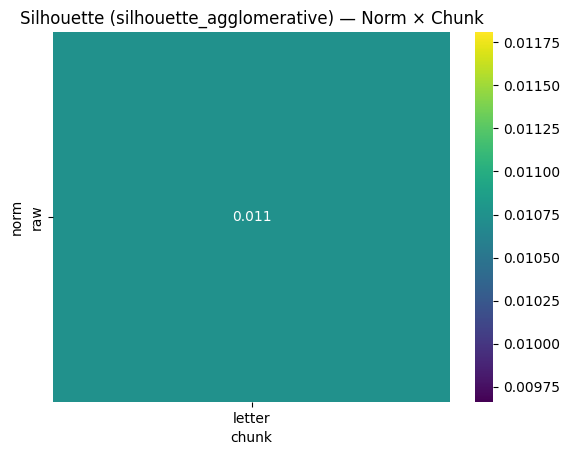

In [4]:
# Heatmap: Silhouette über Norm × Chunk
metric = 'silhouette_hdbscan'
pivot = df.pivot_table(index='norm', columns='chunk', values=metric)
if pivot.empty or pivot.isna().all(axis=None):
    metric = 'silhouette_agglomerative'
    pivot = df.pivot_table(index='norm', columns='chunk', values=metric)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title(f'Silhouette ({metric}) — Norm × Chunk');

In [3]:
# AMI-Differenz: Inhalt vs. Adressat-Trivialisierung
df['content_lift'] = df['silhouette_hdbscan'] - df['ami_hdb_vs_addressee']
df[['silhouette_hdbscan', 'ami_hdb_vs_addressee', 'ami_hdb_vs_decade', 'content_lift']].round(3)

,silhouette_hdbscan,ami_hdb_vs_addressee,ami_hdb_vs_decade,content_lift
variant,,,,
jp_raw_letter_me5l,NaN,1.0,1.0,NaN


## Diskussion (post-hoc auszufüllen)

- Welche Variante gewinnt auf welcher Metrik?
- Korrespondent-AMI: erwartet hoch — aber wie hoch ist zu hoch?
- Qualitative Stichproben: 3 Cluster pro Gewinner-Variante manuell prüfen.
